# Import libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


# EDA
    # 1-info
    # 2-describe
    # 3-is nan
    # 4-duplicates
    # 5-is null
    # 6-heat map to see correlation between columns


In [5]:
df=pd.read_csv('house_predict.csv')
df.head() # price is target 

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,2,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,3,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,4,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,5,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


In [6]:
df.drop('ID',axis=1,inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Square_Feet         500 non-null    float64
 1   Num_Bedrooms        500 non-null    int64  
 2   Num_Bathrooms       500 non-null    int64  
 3   Num_Floors          500 non-null    int64  
 4   Year_Built          500 non-null    int64  
 5   Has_Garden          500 non-null    int64  
 6   Has_Pool            500 non-null    int64  
 7   Garage_Size         500 non-null    int64  
 8   Location_Score      500 non-null    float64
 9   Distance_to_Center  500 non-null    float64
 10  Price               500 non-null    float64
dtypes: float64(4), int64(7)
memory usage: 43.1 KB


In [8]:
df.describe()

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,174.640428,2.958000,1.976000,1.964000,1957.604000,0.536000,0.492000,30.174000,5.164410,10.469641,582209.629529
std,74.672102,1.440968,0.820225,0.802491,35.491781,0.499202,0.500437,11.582575,2.853489,5.588197,122273.390345
min,51.265396,1.000000,1.000000,1.000000,1900.000000,0.000000,0.000000,10.000000,0.004428,0.062818,276892.470136
25%,110.319923,2.000000,1.000000,1.000000,1926.000000,0.000000,0.000000,20.000000,2.760650,6.066754,503080.344140
50%,178.290937,3.000000,2.000000,2.000000,1959.000000,1.000000,0.000000,30.000000,5.206518,10.886066,574724.113347
75%,239.031220,4.000000,3.000000,3.000000,1988.000000,1.000000,1.000000,41.000000,7.732933,15.072590,665942.301274
max,298.241199,5.000000,3.000000,3.000000,2022.000000,1.000000,1.000000,49.000000,9.995439,19.927966,960678.274291


In [9]:
df.isna().sum()

Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Year_Built            0
Has_Garden            0
Has_Pool              0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Year_Built            0
Has_Garden            0
Has_Pool              0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64

<Axes: >

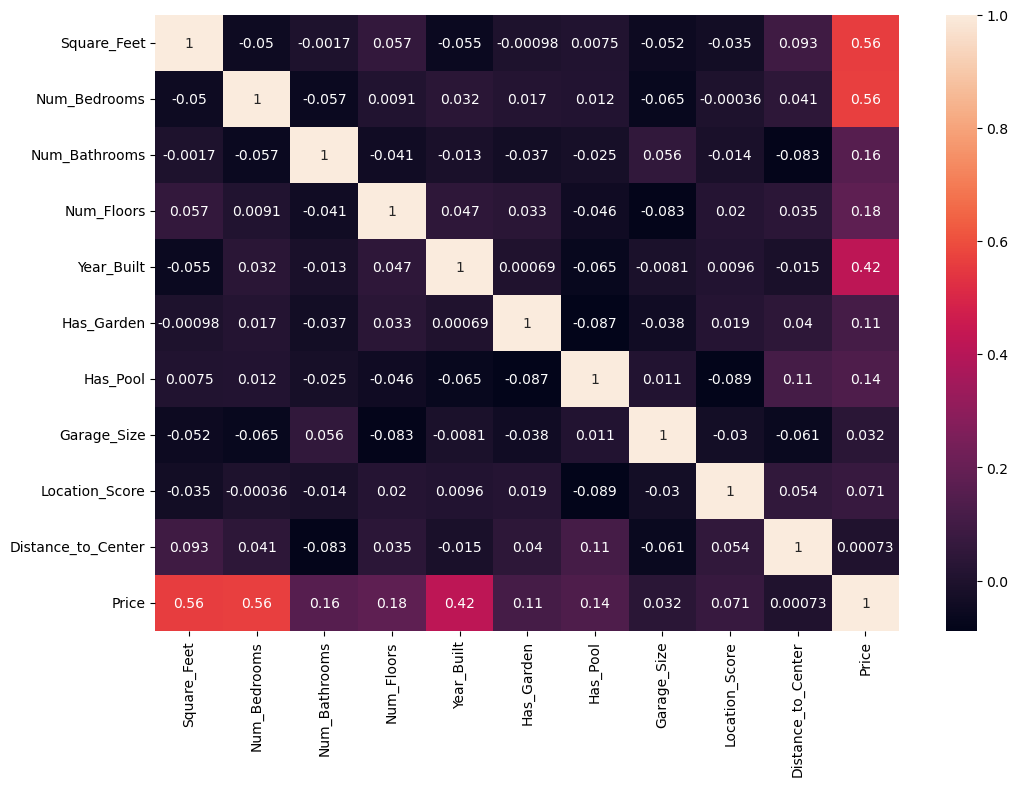

In [12]:
plt.figure(figsize=(12,8))
numeric_col=df.select_dtypes(include=('float64','int64'))
sns.heatmap(numeric_col.corr(),annot=True)

# most columns effects square_feet and number_of_rooms

# preprocessing 

 # 1- Scaling
 # 2- Train_Test_Split
 # 3- I'am not use encoding bec i don't have any categorical data

In [13]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [14]:
df.shape

(500, 11)

In [15]:
x=df.drop('Price',axis=1)
y=df[['Price']] # i use 2 practices to transform column to data frame

In [16]:
min_max_scalling=MinMaxScaler()

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [18]:
x.columns

Index(['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors',
       'Year_Built', 'Has_Garden', 'Has_Pool', 'Garage_Size', 'Location_Score',
       'Distance_to_Center'],
      dtype='object')

In [19]:
numeric_col=['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors','Year_Built', 'Has_Garden', 'Has_Pool', 'Garage_Size', 'Location_Score','Distance_to_Center']

In [20]:
x_train=min_max_scalling.fit_transform(x_train[numeric_col])
x_test=min_max_scalling.transform(x_test[numeric_col])

In [21]:
x_train

array([[0.8604733 , 0.5       , 1.        , ..., 0.15384615, 0.31182152,
        0.05785409],
       [0.09748006, 1.        , 0.        , ..., 0.15384615, 0.49943791,
        0.67581551],
       [0.29039467, 1.        , 0.5       , ..., 0.46153846, 0.77718381,
        0.41438899],
       ...,
       [0.37500984, 0.75      , 1.        , ..., 0.71794872, 0.5637239 ,
        0.66554834],
       [0.70618712, 0.        , 0.5       , ..., 0.43589744, 0.14407435,
        0.04259882],
       [0.31386313, 0.        , 0.5       , ..., 0.66666667, 0.04565499,
        0.42580108]])

In [22]:
x_test

array([[6.47654175e-01, 2.50000000e-01, 0.00000000e+00, 5.00000000e-01,
        7.41666667e-01, 0.00000000e+00, 1.00000000e+00, 6.92307692e-01,
        6.24496115e-03, 6.59387674e-01],
       [8.22370635e-01, 5.00000000e-01, 5.00000000e-01, 5.00000000e-01,
        6.00000000e-01, 1.00000000e+00, 0.00000000e+00, 7.94871795e-01,
        4.58933216e-01, 7.44963635e-01],
       [6.71038580e-02, 7.50000000e-01, 0.00000000e+00, 0.00000000e+00,
        4.91666667e-01, 1.00000000e+00, 1.00000000e+00, 1.28205128e-01,
        7.39630274e-01, 8.72347075e-01],
       [2.40494431e-01, 0.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.66666667e-01, 1.00000000e+00, 1.00000000e+00, 6.92307692e-01,
        8.89243951e-01, 4.61493695e-01],
       [9.15836207e-01, 7.50000000e-01, 0.00000000e+00, 0.00000000e+00,
        3.58333333e-01, 1.00000000e+00, 1.00000000e+00, 9.48717949e-01,
        1.77604985e-01, 5.21448208e-01],
       [3.40701356e-01, 7.50000000e-01, 5.00000000e-01, 1.00000000e+00,
   

# Model 
     I will use algorithm linear regression to predict price of house 

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error
from sklearn.ensemble import RandomForestClassifier

In [24]:
Model=LinearRegression()

In [25]:
Model.fit(x_train,y_train)

LinearRegression()

In [26]:
ypred=Model.predict(x_test)

In [27]:
y_test

,Price
361,591058.708950
73,667693.000276
374,532377.580195
155,478489.299027
104,730197.480607
...,...
347,464849.917757
86,572360.649869
75,557752.837359
438,649930.052338


In [28]:
ypred

array([[575183.6265983 ],
       [680721.17570791],
       [498698.99372393],
       [480419.39772538],
       [708317.31179328],
       [533722.54028076],
       [365788.68154373],
       [566216.94942097],
       [559065.24516452],
       [716345.60198604],
       [531271.02442728],
       [502370.20190522],
       [465410.02768303],
       [452170.05740786],
       [550144.972034  ],
       [727367.00599424],
       [494069.12547414],
       [434732.15204783],
       [764241.5704061 ],
       [705058.73179503],
       [714850.73896965],
       [553545.98674554],
       [736264.5350584 ],
       [343204.13173806],
       [819951.74280084],
       [602333.0693934 ],
       [390955.25888875],
       [603477.53348759],
       [638076.33900743],
       [453637.91628501],
       [663461.50345562],
       [827074.8284106 ],
       [619640.81576249],
       [485962.12763877],
       [492162.17348476],
       [698922.17147201],
       [335166.91170072],
       [601676.35228316],
       [3743

In [29]:
R2=r2_score(y_test,ypred)
print("The R2 score is " ,R2)

The R2 score is  0.970899139169718


# The R2 score is  0.970899139169718


In [30]:
MSE=mean_squared_error(y_test,ypred)
print("The MSE score is " ,MSE)

The MSE score is  437730359.7082726


# The MSE score is  437730359.7082726


In [31]:
MAE=mean_absolute_error(y_test,ypred)
print("The MAE score is " ,MAE)

The MAE score is  16850.995604842246


# The MAE score is  16850.995604842246


In [32]:
import joblib

In [34]:
joblib.dump(Model,"model_h.pkl")

['model_h.pkl']